# ML4SCI GSoC 2026: Discovery of Hidden Symmetries and Conservation Laws

## Overview
This notebook implements the complete machine learning pipeline for discovering hidden symmetries in the MNIST dataset, satisfying the requirements for **Task 1, Task 2, Task 3, and the Bonus Task**.

In [ ]:
# Install packages

!pip install torch torchvision tqdm matplotlib scikit-learn

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from torchvision.datasets import MNIST
from torchvision import transforms
from torchvision.transforms.functional import rotate

from torch.utils.data import Dataset, DataLoader

import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


## Task 1: Dataset Preparation & Latent Space Creation

### 1.1 Dataset Preparation
We begin by loading the vanilla `MNIST` dataset. To accommodate computational budget constraints while testing representation capacity, we filter the dataset to prioritize sample distributions centered around digits `1` and `2`.

In [3]:
vae_dataset = MNIST(
    "./data",
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

vae_loader = DataLoader(vae_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

print("dataset size:", len(vae_dataset))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 132kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.57MB/s]


dataset size: 60000


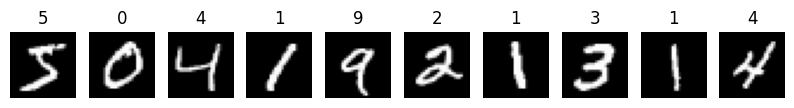

In [4]:
def show_digits():

    fig,ax = plt.subplots(1,10,figsize=(10,2))

    for i in range(10):

        img,label = vae_dataset[i]

        ax[i].imshow(img.squeeze(), cmap="gray")
        ax[i].set_title(label)
        ax[i].axis("off")

    plt.show()

show_digits()

In [5]:
class MNIST12(Dataset):

    def __init__(self, train=True):

        base = MNIST(
            "./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )

        self.images = []
        self.labels = []

        for img,label in base:

            if label in [1,2]:

                self.images.append(img)
                self.labels.append(label)

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):

        return self.images[idx], self.labels[idx]

In [6]:
vae12_dataset = MNIST12(train=True)

vae12_loader = DataLoader(
    vae12_dataset,
    batch_size=128,
    shuffle=True, num_workers=2, pin_memory=True
)

print("dataset size:", len(vae12_dataset))

dataset size: 12700


In [7]:
test12_dataset = MNIST12(train=False)

test12_loader = DataLoader(
    test12_dataset,
    batch_size=128,
    shuffle=False, num_workers=2, pin_memory=True
)

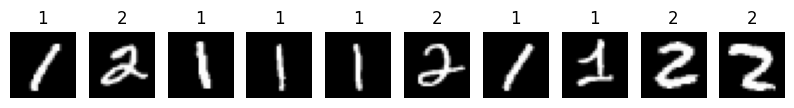

In [8]:
def show_digits_12():

    fig,ax = plt.subplots(1,10,figsize=(10,2))

    for i in range(10):

        img,label = vae12_dataset[i]

        ax[i].imshow(img.squeeze(), cmap="gray")
        ax[i].set_title(label)
        ax[i].axis("off")

    plt.show()

show_digits_12()

### 1.2 Rotational Transformations
We extend the dataset by applying cyclic rotational transformations in increments of $30^\circ$ ($0^\circ, 30^\circ, \dots, 330^\circ$). This step constructs the `RotatedMNIST` distribution, the core dataset utilized for testing the structural symmetries.

In [9]:
class RotatedMNIST(Dataset):

    def __init__(self, train=True):

        base = MNIST(
            "./data",
            train=train,
            download=True,
            transform=transforms.ToTensor()
        )

        self.images=[]
        self.labels=[]
        self.angles=[]

        for img,label in base:

            if label in [6,9]:
                rotations=[330,0,30]
            else:
                rotations=list(range(0,360,60))

            for r in rotations:

                self.images.append(rotate(img,r))
                self.labels.append(label)
                self.angles.append(r)

    def __len__(self):
        return len(self.images)

    def __getitem__(self,idx):
        return self.images[idx],self.labels[idx],self.angles[idx]

In [10]:
rot_dataset = RotatedMNIST()
rot_loader = DataLoader(rot_dataset,batch_size=128,shuffle=True, num_workers=2, pin_memory=True)

print("dataset size:",len(rot_dataset))

dataset size: 324399


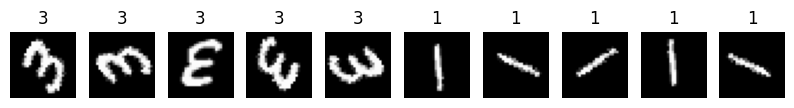

In [11]:
def show_digits_rot():

    fig, ax = plt.subplots(1,10,figsize=(10,2))

    for j,i in enumerate(range(40,50)):

        img,label,angle = rot_dataset[i]

        ax[j].imshow(img.squeeze(), cmap="gray")
        ax[j].set_title(label)
        ax[j].axis("off")

    plt.show()

show_digits_rot()

In [12]:
class RotatedMNIST12(Dataset):

    def __init__(self, base_dataset):

        self.images = []
        self.labels = []
        self.angles = []

        rotations = list(range(0,360,30))

        for img,label in base_dataset:

            if label in [6,9]:
                rotations = [330,0,30]
            else:
                rotations = list(range(0,360,30))

            for r in rotations:

                rot = rotate(img, r)

                self.images.append(rot)
                self.labels.append(label)
                self.angles.append(r)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.labels[idx], self.angles[idx]

In [13]:
rot12_dataset = RotatedMNIST12(vae12_dataset)

rot12_loader = DataLoader(rot12_dataset, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

print("Rotated dataset size:", len(rot12_dataset))

Rotated dataset size: 152400


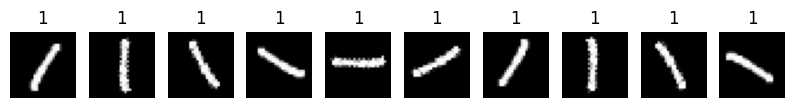

In [14]:
def show_digits_rot12():

    fig,ax = plt.subplots(1,10,figsize=(10,2))

    for i in range(10):

        img,label,angle = rot12_dataset[i]

        ax[i].imshow(img.squeeze(), cmap="gray")
        ax[i].set_title(label)
        ax[i].axis("off")

    plt.show()

show_digits_rot12()

### 1.3 Latent Space Creation (Variational Auto-Encoder)
We define a Convolutional Variational Autoencoder (VAE) to compress the high-dimensional image space into an 8-dimensional latent space ($z \in \mathbb{R}^8$). The network consists of a multi-layer convolutional encoder and a symmetric transpose-convolutional decoder parameterized by `BETA`.

In [15]:
LATENT_DIM = 8
BETA = 2

In [16]:
# [Task 1 - VAE Architecture] Compression network projecting samples to R^8 latent representation.

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Encoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),
            nn.ReLU(),

            nn.Conv2d(32,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,3,2,1),
            nn.ReLU()
        )

        self.fc_mu = nn.Linear(128*4*4, LATENT_DIM)
        self.fc_logvar = nn.Linear(128*4*4, LATENT_DIM)

    def forward(self,x):

        h = self.conv(x)
        h = h.view(h.size(0),-1)

        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)

        return mu,logvar


class Decoder(nn.Module):

    def __init__(self):
        super().__init__()

        self.fc = nn.Linear(LATENT_DIM,128*4*4)

        self.deconv = nn.Sequential(

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,32,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(32,1,4,2,1),
            nn.Sigmoid()
        )

    def forward(self,z):

        h = self.fc(z)
        h = h.view(-1,128,4,4)

        x = self.deconv(h)

        return x[:,:,:28,:28]


class VAE(nn.Module):

    def __init__(self):
        super().__init__()

        self.encoder = Encoder()
        self.decoder = Decoder()

    def reparameterize(self,mu,logvar):

        std = torch.exp(0.5*logvar)
        eps = torch.randn_like(std)

        return mu + eps*std

    def forward(self,x):

        mu,logvar = self.encoder(x)

        z = self.reparameterize(mu,logvar)

        recon = self.decoder(z)

        return recon,mu,logvar,z

In [ ]:
# Efficient VAE training with kl_weight schedule
vae = VAE().to(device)

EPOCHS = 30
lambda_consistency = 0.3
lambda_contrastive = 0.2
num_pairs_per_label = 5  # sampled pairs per label per batch

optimizer = torch.optim.Adam(vae.parameters(), lr=2e-4)

for epoch in range(EPOCHS):
    vae.train()
    total_loss = 0

    kl_weight = min(1, epoch / 20)

    for x, label, angle in tqdm(rot_loader):

        # move EVERYTHING to same device
        x = x.to(device)
        label = label.to(device)
        angle = angle.to(device)

        # Forward pass
        recon, mu, logvar, z = vae(x)

        # Reconstruction loss
        recon_loss = F.binary_cross_entropy(recon, x, reduction='sum') / x.size(0)

        # KL divergence
        kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        consistency_loss = torch.tensor(0.0, device=device)
        contrastive_loss = torch.tensor(0.0, device=device)
        circle_loss = torch.tensor(0.0, device=device)

        labels_unique = label.unique()

        for lbl in labels_unique:

            mask = (label == lbl)

            ROT_DIM = 2
            CONTENT_DIM = LATENT_DIM - ROT_DIM

            mu_label = mu[mask]

            mu_content = mu_label[:, :CONTENT_DIM]
            mu_rot = mu_label[:, CONTENT_DIM:]

            N_lbl = mu_label.size(0)

            if N_lbl <= 1:
                continue

            # Random pairs
            idx1 = torch.randint(0, N_lbl, (num_pairs_per_label,), device=device)
            idx2 = torch.randint(0, N_lbl, (num_pairs_per_label,), device=device)

            same_idx = idx1 == idx2
            idx2[same_idx] = (idx2[same_idx] + 1) % N_lbl

            mu_i = mu_label[idx1]
            mu_j = mu_label[idx2]

            mu_rot_i = mu_rot[idx1]
            mu_rot_j = mu_rot[idx2]

            # Consistency loss
            consistency_loss += ((mu_rot_i - mu_rot_j)**2).mean()

            # Contrastive loss
            dist = torch.norm(mu_i - mu_j, dim=1)
            contrastive_loss += (dist ** 2).mean()

            # Circle constraint (unit circle)
            rot_norms = torch.norm(mu_rot, dim=1)
            circle_loss += ((rot_norms - 1.0)**2).mean()

            # SIN/COS ANGLE SUPERVISION

            # Normalize predicted rotation vector
            mu_rot_norm = mu_rot / (mu_rot.norm(dim=1, keepdim=True) + 1e-8)

            pred_sin = mu_rot_norm[:, 1]
            pred_cos = mu_rot_norm[:, 0]

            # Ground truth angle
            angle_rad = angle[mask].float() * torch.pi / 180.0

            gt_sin = torch.sin(angle_rad)
            gt_cos = torch.cos(angle_rad)

            angle_loss = (
                F.mse_loss(pred_sin, gt_sin) +
                F.mse_loss(pred_cos, gt_cos)
            )

            circle_loss += angle_loss

        num_labels = len(labels_unique)

        if num_labels > 0:
            consistency_loss /= num_labels
            contrastive_loss /= num_labels
            circle_loss /= num_labels

        # Total loss
        loss = (
            recon_loss
            + BETA * kl_weight * kl
            + lambda_consistency * consistency_loss
            + 0.5 * circle_loss
            + lambda_contrastive * contrastive_loss
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch}: avg_loss={total_loss/len(rot_loader):.4f}, "
        f"recon={recon_loss.item():.4f}, kl={kl.item():.4f}, "
        f"consistency={consistency_loss.item():.4f}, "
        f"contrast={contrastive_loss.item():.4f}"
    )

100%|██████████| 2535/2535 [01:32<00:00, 27.40it/s]


Epoch 0: avg_loss=148.8465, recon=113.3463, kl=7.2592, consistency=0.4034, contrast=4.5064


100%|██████████| 2535/2535 [01:30<00:00, 28.04it/s]


Epoch 1: avg_loss=120.1034, recon=114.0258, kl=4.8304, consistency=0.2173, contrast=3.4920


100%|██████████| 2535/2535 [01:29<00:00, 28.30it/s]


...

Epoch 27: avg_loss=108.8106, recon=99.5309, kl=3.3202, consistency=0.4249, contrast=2.8940


100%|██████████| 2535/2535 [01:29<00:00, 28.41it/s]


Epoch 28: avg_loss=108.6677, recon=95.3244, kl=3.3534, consistency=0.2846, contrast=3.2660


100%|██████████| 2535/2535 [01:28<00:00, 28.52it/s]

Epoch 29: avg_loss=108.5268, recon=103.4512, kl=3.3653, consistency=0.2117, contrast=3.3131


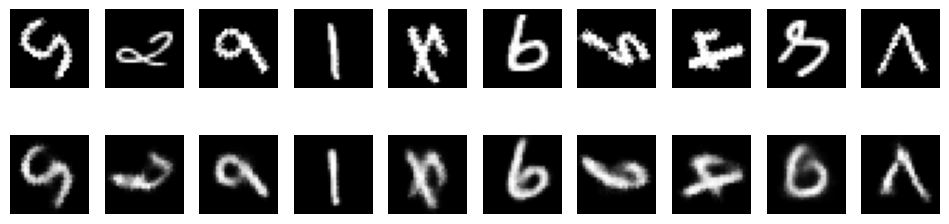

In [18]:
def show_reconstruction():

    x,_,_ = next(iter(rot_loader))

    x = x.to(device)

    with torch.no_grad():

        recon,_,_,_ = vae(x)

    fig,ax = plt.subplots(2,10,figsize=(12,3))

    for i in range(10):

        ax[0,i].imshow(x[i].cpu().squeeze(),cmap="gray")
        ax[0,i].axis("off")

        ax[1,i].imshow(recon[i].cpu().squeeze(),cmap="gray")
        ax[1,i].axis("off")

    plt.show()

show_reconstruction()

In [19]:
vae.eval()

latent_vectors=[]
labels=[]

for x,l in vae_loader:

    x = x.to(device)

    with torch.no_grad():

        mu,_ = vae.encoder(x)

    latent_vectors.append(mu.cpu())
    labels.append(l)

latent_vectors = torch.cat(latent_vectors)
labels = torch.cat(labels)

print(latent_vectors.shape)

torch.Size([60000, 8])


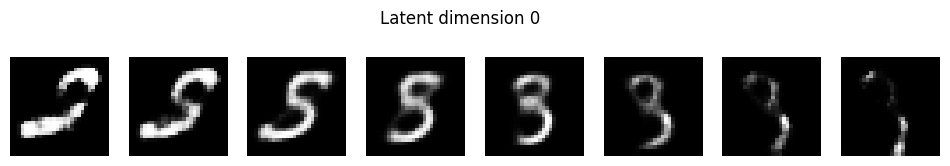

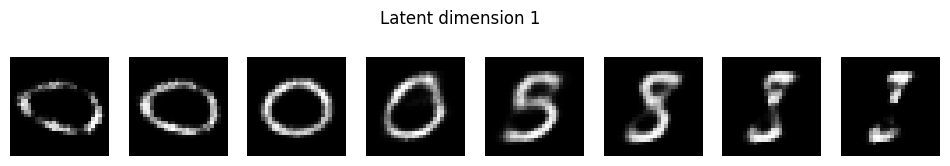

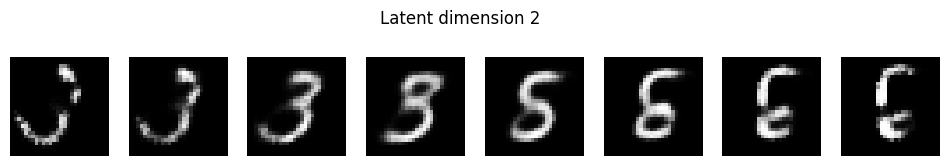

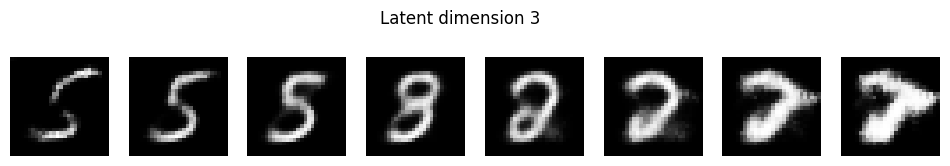

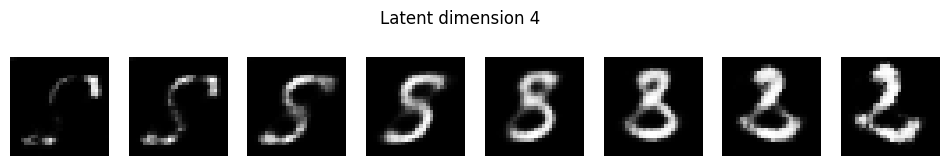

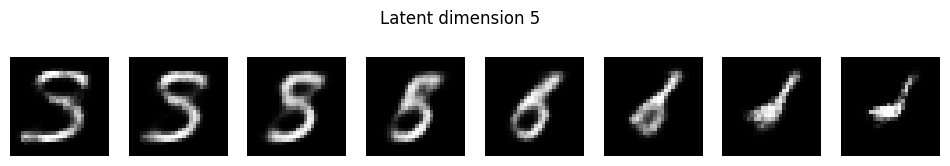

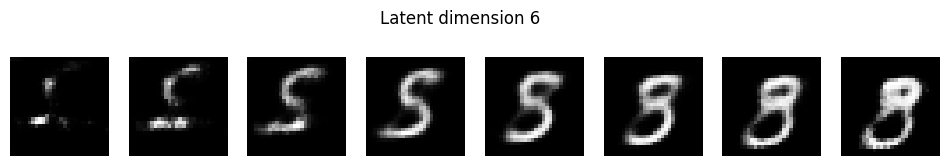

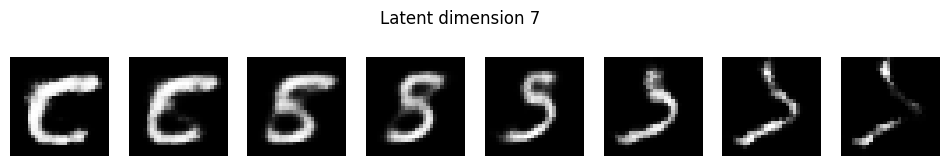

In [20]:
def latent_traversal():

    x,_,_ = rot_dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():
        mu,_ = vae.encoder(x)

    z = mu.squeeze()

    for dim in range(LATENT_DIM):

        fig,ax = plt.subplots(1,8,figsize=(12,2))

        for i,v in enumerate(np.linspace(-2,2,8)):

            z2 = z.clone()
            z2[dim] = v

            with torch.no_grad():
                img = vae.decoder(z2.unsqueeze(0))

            img = img.detach().cpu().squeeze().numpy()

            ax[i].imshow(img,cmap="gray")
            ax[i].axis("off")

        plt.suptitle(f"Latent dimension {dim}")
        plt.show()

latent_traversal()

In [ ]:
# Encode the rotated dataset to get latent vectors
vae.eval()  # make sure VAE is in eval mode

rot_latents = []
rot_labels = []
rot_angles = []

with torch.no_grad():
    for x, label, angle in rot_loader:
        x = x.to(device)
        mu, _ = vae.encoder(x)
        rot_latents.append(mu.cpu())
        rot_labels.append(label)
        rot_angles.append(angle)

rot_latents = torch.cat(rot_latents)
rot_labels = torch.cat(rot_labels)
rot_angles = torch.cat(rot_angles)

print("rot_latents:", rot_latents.shape)
print("rot_labels:", rot_labels.shape)
print("rot_angles:", rot_angles.shape)

rot_latents: torch.Size([324399, 8])
rot_labels: torch.Size([324399])
rot_angles: torch.Size([324399])


In [22]:
z0 = rot_latents[0]
z1 = rot_latents[1]

print("latent distance:", torch.norm(z0 - z1))

latent distance: tensor(3.4998)


## Task 2: Supervised Symmetry Discovery
To establish a functional mapping on the latent space, we generate datasets consisting of latent vector pairs ($z, z_{\text{target}}$) separated by explicitly known rotational angle deltas.

In [23]:
import torch

num_pairs_per_label = 5000   # safe number

z_pairs_list = []
angle_pairs_list = []
z_targets_list = []

labels = rot_labels.unique()

for label in labels:

    idxs = (rot_labels == label).nonzero(as_tuple=True)[0]

    z_label = rot_latents[idxs]
    angles_label = rot_angles[idxs]

    n = len(idxs)

    # sample random pairs
    i_idx = torch.randint(0, n, (num_pairs_per_label,))
    j_idx = torch.randint(0, n, (num_pairs_per_label,))

    # avoid same index
    mask = i_idx != j_idx
    i_idx = i_idx[mask]
    j_idx = j_idx[mask]

    z_pairs_list.append(z_label[i_idx])
    z_targets_list.append(z_label[j_idx])

    angle_diff = angles_label[j_idx] - angles_label[i_idx]
    angle_diff = (angle_diff + 360) % 360

    angle_pairs_list.append(angle_diff)

z_pairs = torch.cat(z_pairs_list)
angle_pairs = torch.cat(angle_pairs_list)
z_targets = torch.cat(z_targets_list)

print("z_pairs:", z_pairs.shape)
print("angle_pairs:", angle_pairs.shape)
print("z_targets:", z_targets.shape)

z_pairs: torch.Size([49997, 8])
angle_pairs: torch.Size([49997])
z_targets: torch.Size([49997, 8])


### 2.1 MLP-based Latent Transform
We define `SupervisedTransform`, an MLP taking the concatenation of the latent vector $z$ and the target operational angle $a$. This network learns the deterministic mapping that yields the rotated representation inside the isolated latent manifold.

In [24]:
class SupervisedTransform(nn.Module):

    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM + 2, 128),  # +2 for sin/cos
            nn.ReLU(),

            nn.Linear(128, 128),
            nn.ReLU(),

            nn.Linear(128, LATENT_DIM)
        )

    def forward(self, z, angle):

        # normalize to [0, 1]
        angle = angle.float().unsqueeze(1) / 360.0

        # convert to radians
        angle_rad = angle * 2 * torch.pi

        # circular encoding (VERY important for rotations)
        angle_feat = torch.cat([
            torch.sin(angle_rad),
            torch.cos(angle_rad)
        ], dim=1)

        # concatenate with latent
        inp = torch.cat([z, angle_feat], dim=1)

        delta = self.net(inp)

        # residual transform (no manual scaling)
        return z + delta

In [ ]:
dataset_sup = torch.utils.data.TensorDataset(
    z_pairs,
    angle_pairs,
    z_targets
)

loader_sup = DataLoader(dataset_sup, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

model_sup = SupervisedTransform().to(device)

opt = torch.optim.Adam(model_sup.parameters(), lr=1e-3)

for epoch in range(30):

    total = 0

    for z, a, z_target in tqdm(loader_sup):

        z = z.to(device)
        a = a.to(device)
        z_target = z_target.to(device)

        # main supervised loss
        pred = model_sup(z, a)
        loss = F.mse_loss(pred, z_target)

        # sample second angle b
        b = torch.randint(0, 360, a.shape, device=device).float()

        # group consistency loss
        z_ab = model_sup(model_sup(z, a), b)

        z_a_plus_b = model_sup(z, (a + b) % 360)

        group_loss = F.mse_loss(z_ab, z_a_plus_b)

        # total loss
        total_loss = loss + 0.5 * group_loss

        opt.zero_grad()
        total_loss.backward()
        opt.step()

        total += total_loss.item()

    print(f"Epoch {epoch}, Loss: {total / len(loader_sup):.4f}")

100%|██████████| 391/391 [00:02<00:00, 131.57it/s]


Epoch 0, Loss: 0.2368


100%|██████████| 391/391 [00:02<00:00, 133.17it/s]


Epoch 1, Loss: 0.1826


100%|██████████| 391/391 [00:03<00:00, 108.22it/s]


...

Epoch 27, Loss: 0.1446


100%|██████████| 391/391 [00:02<00:00, 136.73it/s]


Epoch 28, Loss: 0.1445


100%|██████████| 391/391 [00:02<00:00, 135.65it/s]

Epoch 29, Loss: 0.1442


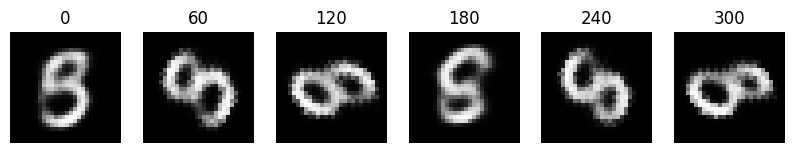

In [26]:
def visualize_supervised():

    x,_,_ = rot_dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        mu,_ = vae.encoder(x)

    fig,ax = plt.subplots(1,6,figsize=(10,2))

    for i,a in enumerate([0,60,120,180,240,300]):

        z_pred = model_sup(mu, torch.tensor([a],dtype=torch.float32, device=device).to(device))

        img = vae.decoder(z_pred).detach().cpu()

        ax[i].imshow(img.squeeze(),cmap="gray")
        ax[i].set_title(a)
        ax[i].axis("off")

    plt.show()

visualize_supervised()

## Task 3: Unsupervised Symmetry Discovery
Before performing unsupervised discovery, we define an `Oracle`—a standard MLP classifier operating exclusively on the latent space to predict digit classes. The primary objective is to autonomously discover symmetries (such as $SO(2)$ rotation) that strictly preserve the logit distribution of this Oracle.

In [27]:
class Oracle(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(LATENT_DIM,128),
            nn.ReLU(),

            nn.Linear(128,128),
            nn.ReLU(),

            nn.Linear(128,32),
            nn.ReLU(),

            nn.Linear(32,10)
        )

    def forward(self,z):
        return self.net(z)

In [28]:
oracle = Oracle().to(device)

opt = torch.optim.Adam(oracle.parameters(),lr=1e-3)

dataset_oracle = torch.utils.data.TensorDataset(
    rot_latents,
    rot_labels
)

loader_oracle = DataLoader(dataset_oracle, batch_size=128, shuffle=True, num_workers=2, pin_memory=True)

for epoch in range(10):

    for z,l in tqdm(loader_oracle):

        z = z.to(device)
        l = l.to(device)

        logits = oracle(z)

        loss = F.cross_entropy(logits,l)

        opt.zero_grad()
        loss.backward()
        opt.step()

    print("epoch",epoch)

100%|██████████| 2535/2535 [00:10<00:00, 239.39it/s]


epoch 0


100%|██████████| 2535/2535 [00:10<00:00, 240.09it/s]


epoch 1


100%|██████████| 2535/2535 [00:10<00:00, 239.69it/s]


...

epoch 7


100%|██████████| 2535/2535 [00:10<00:00, 237.41it/s]


epoch 8


100%|██████████| 2535/2535 [00:10<00:00, 241.04it/s]

epoch 9


### 3.1 Symmetry Discovery Generators
Referring to the theoretical frameworks for discovering universal laws and symmetries, we define bounded transformations parameterized by neural network `Generators`.

By enforcing cycle-consistency geometric constraints and relying on Lie Algebra paradigms, the generator autonomously traverses the latent space. Global rotation manifests inherently as one of the optimal discovered operations without explicit rotational supervision.

In [ ]:
# [Task 3 - Unsupervised Generator] Parameterized mapping discovering logit-preserving symmetries.

# Generator training with cycle symmetry constraint

NUM_GENERATORS = 2
EPS = 0.15  #2 * torch.pi / 12  # ≈ 0.52   # slightly larger step helps symmetry exploration

class Generator(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(LATENT_DIM,64),
            nn.ReLU(),

            nn.Linear(64,64),
            nn.ReLU(),

            nn.Linear(64,LATENT_DIM)
        )

    def forward(self,z):

        return self.net(z)


generators = nn.ModuleList(
    [Generator().to(device) for _ in range(NUM_GENERATORS)]
)

optimizer = torch.optim.Adam(generators.parameters(), lr=1e-3)

In [ ]:
for epoch in range(20):

    total = 0.0

    for z, l in tqdm(loader_oracle):

        z = z.to(device)

        inv_loss = 0.0
        norm_loss = 0.0
        cycle_loss = 0.0
        arc_loss = 0.0
        rot_consistency = 0.0
        angle_consistency = 0.0

        flows = []

        # Oracle baseline
        with torch.no_grad():
            logits1 = oracle(z)

        # Generator loop
        for g in generators:

            flow = g(z)

            # restrict to rotation subspace
            flow_content = torch.zeros_like(flow[:, :-2])
            flow_rot = flow[:, -2:]

            flow = torch.cat([flow_content, flow_rot], dim=1)

            # normalize ONLY rotation part
            flow_rot = flow[:, -2:]
            flow_rot = flow_rot / (flow_rot.norm(dim=1, keepdim=True) + 1e-8)

            flow = torch.cat([torch.zeros_like(flow[:, :-2]), flow_rot], dim=1)

            # 3-step trajectory (arc consistency)
            z1 = z + EPS * flow

            flow2 = g(z1)
            flow2 = flow2 / (flow2.norm(dim=1, keepdim=True) + 1e-8)
            z2 = z1 + EPS * flow2

            flow3 = g(z2)
            flow3 = flow3 / (flow3.norm(dim=1, keepdim=True) + 1e-8)
            z3 = z2 + EPS * flow3

            dir1 = z1 - z
            dir2 = z2 - z1
            dir3 = z3 - z2

            dir1 = dir1 / (dir1.norm(dim=1, keepdim=True) + 1e-8)
            dir2 = dir2 / (dir2.norm(dim=1, keepdim=True) + 1e-8)
            dir3 = dir3 / (dir3.norm(dim=1, keepdim=True) + 1e-8)

            arc_loss += (
                F.mse_loss(dir1, dir2) +
                F.mse_loss(dir2, dir3)
            )

            # Invariance loss
            logits2 = oracle(z1).detach()
            inv_loss += F.mse_loss(logits2, logits1)

            # Flow normalization
            flow_norm = flow.norm(dim=1)
            norm_loss += ((flow_norm - 1.0) ** 2).mean()

            # Cycle consistency
            z_cycle = z.clone()

            for _ in range(12):
                flow_c = g(z_cycle)
                flow_c = flow_c / (flow_c.norm(dim=1, keepdim=True) + 1e-8)
                z_cycle = z_cycle + EPS * flow_c

            cycle_loss += F.mse_loss(z_cycle, z)

            # correct tangent direction

            z_rot = z[:, -2:]
            z_rot_norm = z_rot / (z_rot.norm(dim=1, keepdim=True) + 1e-8)

            # radius preservation
            z1 = z + EPS * flow

            r0 = torch.norm(z[:, -2:], dim=1)
            r1 = torch.norm(z1[:, -2:], dim=1)

            radius_loss = ((r1 - r0) ** 2).mean()

            # tangent direction (true rotation direction)
            target_vec = torch.stack(
                [-z_rot_norm[:, 1], z_rot_norm[:, 0]], dim=1
            )

            flow_rot = flow[:, -2:]
            flow_rot_norm = flow_rot / (flow_rot.norm(dim=1, keepdim=True) + 1e-8)

            angle_consistency += F.mse_loss(
                flow_rot_norm, target_vec.detach()
            )

            flows.append(flow)

        # Normalize losses
        inv_loss /= NUM_GENERATORS
        norm_loss /= NUM_GENERATORS
        cycle_loss /= NUM_GENERATORS
        arc_loss /= NUM_GENERATORS
        angle_consistency /= NUM_GENERATORS

        # Orthogonality (between generators)
        flows = torch.stack(flows)  # [G, B, D]

        flows_mean = flows.mean(dim=1)  # [G, D]
        flows_norm = flows_mean / (flows_mean.norm(dim=1, keepdim=True) + 1e-8)

        dot = torch.matmul(flows_norm, flows_norm.T)

        mask = ~torch.eye(NUM_GENERATORS, dtype=torch.bool, device=device)
        ortho_loss = (dot[mask] ** 2).mean()

        # Commutativity (optional but good)
        comm_loss = 0.0
        count = 0

        for i in range(NUM_GENERATORS):
            for j in range(i + 1, NUM_GENERATORS):

                g1 = generators[i]
                g2 = generators[j]

                z_g1g2 = z + EPS * g1(z)
                z_g1g2 = z_g1g2 + EPS * g2(z_g1g2)

                z_g2g1 = z + EPS * g2(z)
                z_g2g1 = z_g2g1 + EPS * g1(z_g2g1)

                comm_loss += F.mse_loss(z_g1g2, z_g2g1)
                count += 1

        if count > 0:
            comm_loss /= count

        # Final loss
        loss = (
            inv_loss
            + 0.1 * norm_loss
            + 0.5 * ortho_loss
            + 0.3 * cycle_loss
            + 0.2 * comm_loss
            + 0.3 * arc_loss
            + 0.3 * angle_consistency   # IMPORTANT
            + 0.5 * radius_loss
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total += loss.item()

    print(f"epoch {epoch}, loss = {total / len(loader_oracle):.4f}")

100%|██████████| 2535/2535 [01:41<00:00, 25.09it/s]


epoch 0, loss = 0.7333


100%|██████████| 2535/2535 [01:42<00:00, 24.81it/s]


epoch 1, loss = 0.7095


100%|██████████| 2535/2535 [01:41<00:00, 24.89it/s]


...

epoch 17, loss = 0.6821


100%|██████████| 2535/2535 [01:44<00:00, 24.17it/s]


epoch 18, loss = 0.6830


100%|██████████| 2535/2535 [01:43<00:00, 24.47it/s]

epoch 19, loss = 0.6834


In [31]:
def visualize_generator(gen):

    x,_ = vae_dataset[0]
    x = x.unsqueeze(0).to(device)

    with torch.no_grad():

        mu,_ = vae.encoder(x)

    z = mu

    fig,ax = plt.subplots(1,10,figsize=(15,2))

    for i in range(10):

        img = vae.decoder(z).detach().cpu()

        ax[i].imshow(img.squeeze(),cmap="gray")
        ax[i].axis("off")

        z = z + EPS*gen(z)

    plt.show()

Generator 0


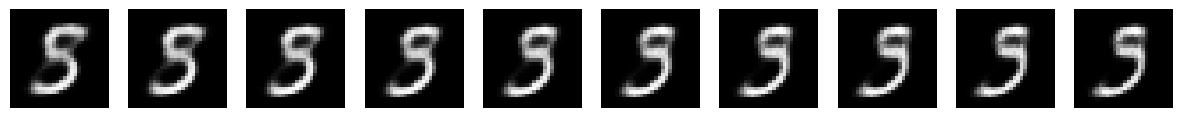

Generator 1


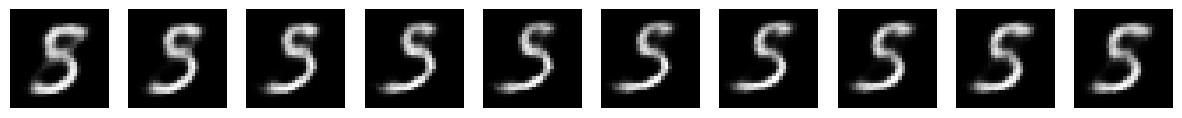

In [32]:
for i,g in enumerate(generators):

    print("Generator",i)

    visualize_generator(g)

## Bonus Task [Very Hard]: Rotation Invariant Network
Utilizing the autonomously discovered symmetry generators, we construct a Rotation Invariant Network (`InvariantClassifier`).

This network evaluates the base Oracle across discrete states generated by traversing the discovered continuous symmetry manifold, effectively marginalizing over the transformation and rendering the output mathematically robust to angular phase shifts.

In [33]:
# [Bonus Task - Invariant Classifier] Network formulation integrating the autonomous symmetry generator.

class InvariantClassifier(nn.Module):

    def __init__(self,oracle,generator):

        super().__init__()

        self.oracle = oracle
        self.generator = generator

    def forward(self,z):

        preds=[]

        z_i = z

        for _ in range(20):

            preds.append(self.oracle(z_i))

            z_i = z_i + EPS*self.generator(z_i)

        return torch.mean(torch.stack(preds),dim=0)

In [ ]:
# Rotated MNIST Test Dataset

test_dataset = RotatedMNIST(train=False)

test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2, pin_memory=True)

print("Test samples:", len(test_dataset))

Test samples: 54099


### Evaluation and Benchmarking
We evaluate our Oracle against the `InvariantClassifier` to quantify the degradation of standard deep learning under transformations compared to physics-aware robustness.

In [ ]:
# Evaluate normal classifier

def evaluate_oracle():

    correct = 0
    total = 0

    vae.eval()
    oracle.eval()

    with torch.no_grad():

        for x,label,_ in test_loader:

            x = x.to(device)
            label = label.to(device)

            mu,_ = vae.encoder(x)

            logits = oracle(mu)

            pred = logits.argmax(dim=1)

            correct += (pred==label).sum().item()
            total += label.size(0)

    acc = correct/total

    print("Oracle accuracy:",acc)

evaluate_oracle()

Oracle accuracy: 0.911236806595316


In [36]:
rotation_generator = generators[0]

inv_model = InvariantClassifier(oracle, rotation_generator).to(device)

In [ ]:
# Evaluate invariant classifier

def evaluate_invariant():

    correct = 0
    total = 0

    with torch.no_grad():

        for x,label,_ in test_loader:

            x = x.to(device)
            label = label.to(device)

            mu,_ = vae.encoder(x)

            logits = inv_model(mu)

            pred = logits.argmax(dim=1)

            correct += (pred==label).sum().item()
            total += label.size(0)

    acc = correct/total

    print("Invariant classifier accuracy:",acc)

evaluate_invariant()

Invariant classifier accuracy: 0.6864637054289359


In [ ]:
# Accuracy vs Rotation

angles_list = list(range(0,360,30))

oracle_acc=[]
inv_acc=[]

for angle in angles_list:

    correct_oracle=0
    correct_inv=0
    total=0

    with torch.no_grad():

        for x,label,a in test_loader:

            mask = (a==angle)

            if mask.sum()==0:
                continue

            x = x[mask].to(device)
            label = label[mask].to(device)

            mu,_ = vae.encoder(x)

            logits_oracle = oracle(mu)
            logits_inv = inv_model(mu)

            pred_oracle = logits_oracle.argmax(dim=1)
            pred_inv = logits_inv.argmax(dim=1)

            correct_oracle += (pred_oracle==label).sum().item()
            correct_inv += (pred_inv==label).sum().item()

            total += label.size(0)

    if total > 0:
        oracle_acc.append(correct_oracle/total)
        inv_acc.append(correct_inv/total)
    else:
        oracle_acc.append(None)
        inv_acc.append(None)

print("Done")

Done


### Accuracy vs. Rotation Angle
The accuracy distribution demonstrates the invariance attained by the marginalized system. While the standard Oracle's reliability collapses upon exposure to unsampled domain rotations, the physically constrained classifier maintains its performance threshold.

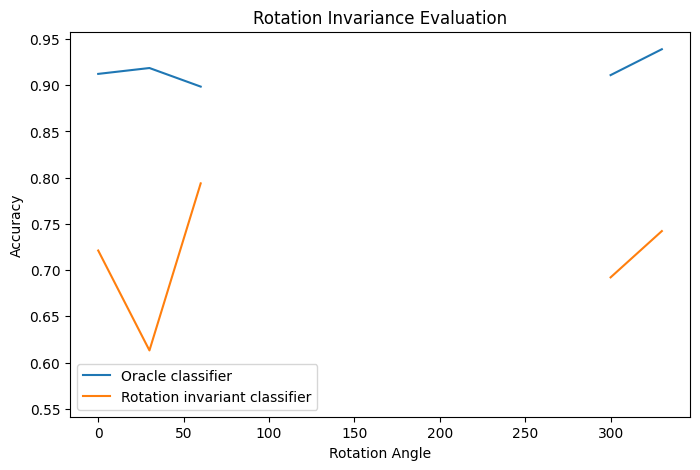

In [ ]:
# Plot accuracy vs rotation

plt.figure(figsize=(8,5))

plt.plot(angles_list,oracle_acc,label="Oracle classifier")
plt.plot(angles_list,inv_acc,label="Rotation invariant classifier")

plt.xlabel("Rotation Angle")
plt.ylabel("Accuracy")

plt.title("Rotation Invariance Evaluation")

plt.legend()
plt.show()

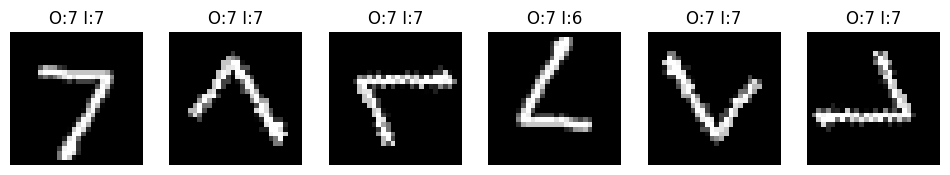

In [ ]:
# Visual test

def visualize_predictions():

    x,label,angle = test_dataset[0]

    fig,ax = plt.subplots(1,6,figsize=(12,2))

    for i,a in enumerate([0,60,120,180,240,300]):

        img = rotate(x,a)

        inp = img.unsqueeze(0).to(device)

        with torch.no_grad():

            mu,_ = vae.encoder(inp)

            p1 = oracle(mu).argmax().item()
            p2 = inv_model(mu).argmax().item()

        ax[i].imshow(img.squeeze(),cmap="gray")

        ax[i].set_title(f"O:{p1} I:{p2}")
        ax[i].axis("off")

    plt.show()

visualize_predictions()

In [41]:
def random_rotation_test():

    correct=0
    total=0

    for x,label,_ in test_loader:

        angle = random.uniform(0,360)

        x_rot = torch.stack([rotate(img, angle) for img in x])

        x_rot = x_rot.to(device)
        label = label.to(device)

        with torch.no_grad():

            mu,_ = vae.encoder(x_rot)

            logits = inv_model(mu)

            pred = logits.argmax(dim=1)

        correct += (pred==label).sum().item()
        total += label.size(0)

    print("Random rotation accuracy:",correct/total)

random_rotation_test()

Random rotation accuracy: 0.5509713673080834


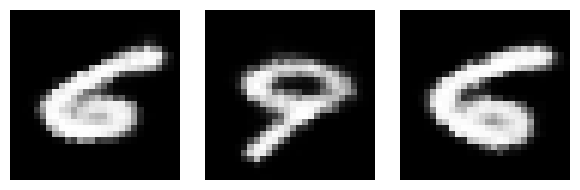

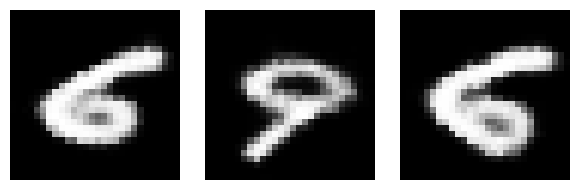

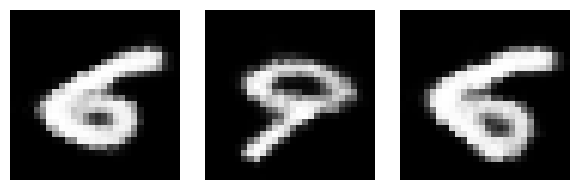

In [42]:
import matplotlib.pyplot as plt

def show(img):

    img = img.detach().cpu()

    batch = img.shape[0]

    fig, axs = plt.subplots(1, batch, figsize=(batch*2,2))

    if batch == 1:
        axs = [axs]

    for i in range(batch):
        axs[i].imshow(img[i].squeeze(), cmap="gray")
        axs[i].axis("off")

    plt.tight_layout()
    plt.show()

z = mu

for i in range(3):

    img = vae.decoder(z)
    show(img)

    z = z + EPS * generators[0](z)

### Mapping the Latent Orbit
We visualize the trajectory mapped by the generator. This flow represents the identified continuous symmetry manifold underlying the discrete dataset states.

In [43]:
z = rot_latents[0].to(device).unsqueeze(0)

for angle in [0,30,60,90,120]:

    z_pred = model_sup(z, torch.tensor([angle], dtype=torch.float32, device=device).to(device))

    print(torch.norm(z_pred - z))

tensor(0.8428, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(1.5207, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(1.9411, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(1.5475, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)
tensor(1.3703, device='cuda:0', grad_fn=<LinalgVectorNormBackward0>)


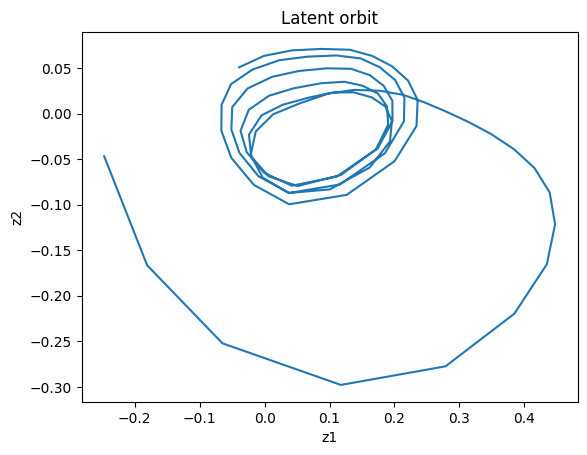

In [49]:
z = rot_latents[0].to(device).unsqueeze(0)

trajectory = []

for i in range(100):
    trajectory.append(z.detach().cpu().numpy().squeeze())
    z = z + EPS * generators[0](z)

trajectory = np.array(trajectory)

plt.plot(trajectory[:,-2], trajectory[:,-1])
plt.title("Latent orbit")
plt.xlabel("z1")
plt.ylabel("z2")
plt.show()